# PINN for the 2D Poisson Equation

This notebook trains a Physics-Informed Neural Network to solve a Dirichlet boundary-value problem for the 2D Poisson equation. The network architecture is defined separately in `model.py`; everything else -- problem setup, data sampling, loss construction, training loop, evaluation and visualization -- lives here so that the whole experiment can be inspected and modified end-to-end in a single notebook.

## Governing equation

We consider the strong form

$$
\begin{aligned}
  -\Delta u(x, y) &= f(x, y), & (x, y) &\in \Omega = (0, 1)^2, \\
  u(x, y) &= 0, & (x, y) &\in \partial\Omega,
\end{aligned}
$$

where the Laplacian is $\Delta u = u_{xx} + u_{yy}$. We use the **method of manufactured solutions** to obtain a reference: pick

$$
u^{\star}(x, y) = \sin(\pi x)\,\sin(\pi y),
$$

substitute into $-\Delta u^{\star} = f$ and obtain

$$
f(x, y) = 2\pi^{2}\,\sin(\pi x)\,\sin(\pi y).
$$

Because $\sin(0) = \sin(\pi) = 0$, the homogeneous Dirichlet condition $u^{\star}|_{\partial\Omega} = 0$ is automatically satisfied on the unit square. Having a closed-form reference means the relative $L^{2}$ error can be computed exactly without a numerical solver.

## Loss function

The composite PINN loss we minimize is

$$
\mathcal{L} \;=\; \mathcal{L}_{f} \;+\; \lambda_{b}\,\mathcal{L}_{b},
$$

with

* **PDE residual loss** $\mathcal{L}_{f}$ -- MSE of $(u_{xx} + u_{yy} + f)$ over interior collocation points;
* **Dirichlet boundary loss** $\mathcal{L}_{b}$ -- MSE of $u$ against $0$ over points sampled on $\partial\Omega$;
* **BC weight** $\lambda_{b}$ -- a scalar set to $1$ here; raising it can help when the network has trouble learning the boundary.

All derivatives in $\mathcal{L}_{f}$ are obtained through PyTorch's automatic differentiation.

## 1. Imports and reproducibility

We import PyTorch, NumPy, matplotlib and `tqdm`, fix the random seeds so that the experiment is reproducible, and select a CUDA device when available. The PINN architecture itself is imported from the sibling module `model.py`.

In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from model import PINN

SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Problem domain and data sampling

The domain is the unit square $\Omega = (0, 1)^{2}$. We draw two disjoint point sets:

| Set | Size | Location | Role |
|---|---|---|---|
| Collocation points | $N_{f} = 10{,}000$ | $(x, y) \sim \mathcal{U}(\Omega)$ | enforce the PDE residual $u_{xx} + u_{yy} + f = 0$ |
| Boundary points | $N_{b} = 400$ (100 per side) | uniformly on each of the four edges of $\partial\Omega$ | enforce $u = 0$ |

Interior tensors carry `requires_grad=True` because the PDE residual needs $u_{xx}$ and $u_{yy}$; boundary tensors are plain data since we only evaluate $u$ (no derivatives) there.

In [10]:
# --- Domain bounds ---------------------------------------------------------
x_lb, x_ub = 0.0, 1.0
y_lb, y_ub = 0.0, 1.0

# --- Sample sizes ----------------------------------------------------------
N_f = 1000   # PDE collocation points
N_bs = 1000    # boundary points PER EDGE (total N_b = 4 * N_bs)

# --- Interior collocation points ------------------------------------------
x_f = np.random.uniform(x_lb, x_ub, (N_f, 1))
y_f = np.random.uniform(y_lb, y_ub, (N_f, 1))

# --- Boundary points: four edges of the unit square -----------------------
s = np.random.uniform(0.0, 1.0, (N_bs, 1))
xb = np.concatenate([np.zeros_like(s), np.ones_like(s),  s,                s               ])
yb = np.concatenate([s,                s,                np.zeros_like(s), np.ones_like(s) ])


def to_tensor(a, requires_grad=False):
    return torch.tensor(a, dtype=torch.float32, device=device, requires_grad=requires_grad)


# Interior tensors need grad for u_xx and u_yy
x_f_t = to_tensor(x_f, requires_grad=True)
y_f_t = to_tensor(y_f, requires_grad=True)

# Boundary tensors (no grad needed -- pure supervision)
x_b_t = to_tensor(xb)
y_b_t = to_tensor(yb)

print(f'Interior collocation : {x_f_t.shape[0]}')
print(f'Boundary points      : {x_b_t.shape[0]}  ({N_bs} per edge)')

Interior collocation : 1000
Boundary points      : 4000  (1000 per edge)


## 3. Model instantiation

We build the PINN defined in `model.py` (a 2-50-50-50-50-1 tanh MLP, Xavier-initialized) and wrap it with the Adam optimizer. A learning rate of $10^{-3}$ is a standard starting point and works well for this smooth, low-frequency benchmark.

In [11]:
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'Total trainable parameters: {n_params:,}')

PINN(
  (linears): ModuleList(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1-3): 3 x Linear(in_features=50, out_features=50, bias=True)
    (4): Linear(in_features=50, out_features=1, bias=True)
  )
  (activation): Tanh()
)
Total trainable parameters: 7,851


## 4. Loss function

We use a small helper `grad(y, x)` that wraps `torch.autograd.grad` with `create_graph=True` so that higher-order derivatives (e.g. $u_{xx}$) can be built on top of first-order ones ($u_{x}$). The function `pde_residual` evaluates $u_{xx} + u_{yy} + f$ and `total_loss` assembles the two MSE terms.

In [12]:
PI = float(np.pi)
LAMBDA_B = 100.0   # Dirichlet-BC weight; raise it if the boundary is under-fit.


def grad(y, x):
    """First derivative dy/dx, preserving the graph for higher-order diff."""
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def pde_residual(model, x, y):
    """Evaluate r(x, y) = u_xx + u_yy + f, which should vanish inside Omega."""
    u = model(x, y)
    u_x  = grad(u, x)
    u_y  = grad(u, y)
    u_xx = grad(u_x, x)
    u_yy = grad(u_y, y)
    f = 2.0 * (PI ** 2) * torch.sin(PI * x) * torch.sin(PI * y)
    return u_xx + u_yy + f


def total_loss(model):
    # --- L_f : PDE residual on interior points ---------------------------
    r = pde_residual(model, x_f_t, y_f_t)
    loss_f = torch.mean(r ** 2)

    # --- L_b : Dirichlet boundary u = 0 ----------------------------------
    u_b = model(x_b_t, y_b_t)
    loss_b = torch.mean(u_b ** 2)

    return loss_f + LAMBDA_B * loss_b, loss_f.item(), loss_b.item()

## 5. Training loop

A full-batch Adam optimizer is run for $10{,}000$ iterations. Because the collocation set is small enough to fit comfortably on a single GPU (or CPU), mini-batching is unnecessary -- every iteration evaluates the loss on all interior and boundary points at once. Progress is streamed through a `tqdm` bar, and every 100 steps its postfix is refreshed with the current decomposition of the loss so that the relative difficulty of the two objectives can be monitored in real time.

In [13]:
n_iters   = 10000

history = []
pbar = tqdm(range(1, n_iters + 1))
for it in pbar:
    optimizer.zero_grad()
    loss, lf, lb = total_loss(model)
    loss.backward()
    optimizer.step()

    history.append((it, loss.item(), lf, lb))

    pbar.set_postfix(total=f'{loss.item():.2e}',
                        PDE=f'{lf:.2e}',
                        BC=f'{lb:.2e}')

100%|██████████| 10000/10000 [02:06<00:00, 79.34it/s, BC=7.07e-07, PDE=3.60e-04, total=4.31e-04]


## 6. Evaluation and error

We evaluate the trained network on a dense $201 \times 201$ grid over $\Omega$ and compare against the analytical solution $u^{\star}(x, y) = \sin(\pi x)\sin(\pi y)$. The scalar diagnostic is the relative $L^{2}$ error

$$
\operatorname{relL2}(u) \;=\; \frac{\lVert u_{\text{pred}} - u^{\star} \rVert_{2}}{\lVert u^{\star} \rVert_{2}}.
$$

In [14]:
model.eval()

N_plot = 201
x_grid = np.linspace(x_lb, x_ub, N_plot)
y_grid = np.linspace(y_lb, y_ub, N_plot)
X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')
x_flat = X.reshape(-1, 1)
y_flat = Y.reshape(-1, 1)

with torch.no_grad():
    u_pred = model(to_tensor(x_flat), to_tensor(y_flat)).cpu().numpy().reshape(N_plot, N_plot)

u_true = np.sin(np.pi * X) * np.sin(np.pi * Y)
err    = u_pred - u_true

rel_l2 = np.linalg.norm(err) / np.linalg.norm(u_true)
max_ae = np.abs(err).max()
print(f'relative L2 error : {rel_l2:.3e}')
print(f'max absolute error: {max_ae:.3e}')

relative L2 error : 9.531e-04
max absolute error: 2.580e-03


## 7. Visualization

Three side-by-side panels: the PINN prediction $u_{\text{pred}}$, the analytical reference $u^{\star}$, and the pointwise absolute error $|u_{\text{pred}} - u^{\star}|$. The prediction and the reference share a common colour scale so that any visible discrepancy is structural rather than due to rescaling; the error panel uses its own scale to highlight spatial patterns in the residual (typically concentrated near the domain centre or the boundary).

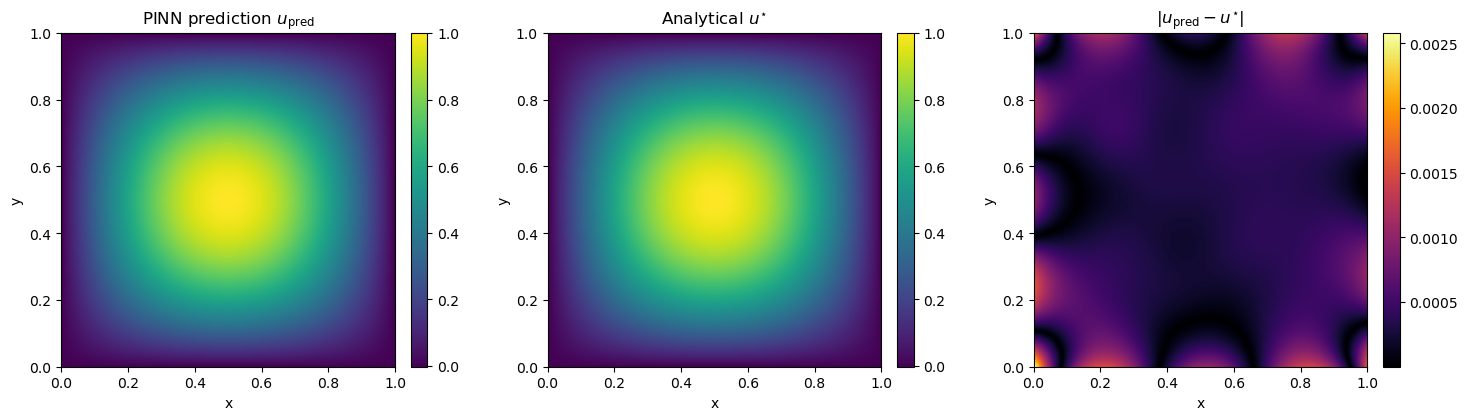

In [15]:
vmin = min(u_pred.min(), u_true.min())
vmax = max(u_pred.max(), u_true.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for ax, field, title in zip(
    axes[:2],
    [u_pred, u_true],
    [r'PINN prediction $u_{\mathrm{pred}}$', r'Analytical $u^{\star}$'],
):
    im = ax.imshow(
        field.T,
        extent=[x_lb, x_ub, y_lb, y_ub],
        origin='lower', aspect='equal', cmap='viridis', vmin=vmin, vmax=vmax,
    )
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

im = axes[2].imshow(
    np.abs(err).T,
    extent=[x_lb, x_ub, y_lb, y_ub],
    origin='lower', aspect='equal', cmap='inferno',
)
axes[2].set_xlabel('x'); axes[2].set_ylabel('y')
axes[2].set_title(r'$|u_{\mathrm{pred}} - u^{\star}|$')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

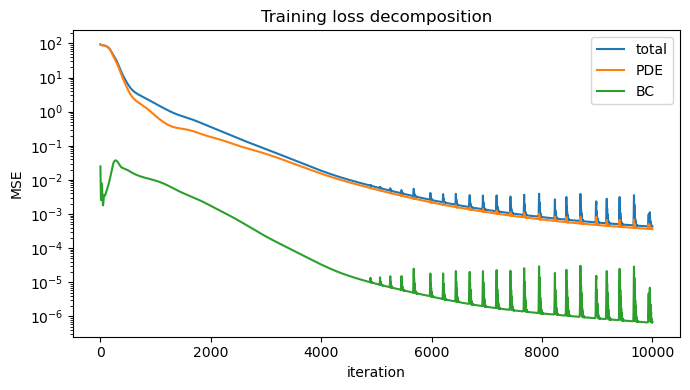

In [16]:
# Loss curves.
hist = np.array(history)
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(hist[:, 0], hist[:, 1], label='total')
ax.semilogy(hist[:, 0], hist[:, 2], label='PDE')
ax.semilogy(hist[:, 0], hist[:, 3], label='BC')
ax.set_xlabel('iteration')
ax.set_ylabel('MSE')
ax.set_title('Training loss decomposition')
ax.legend()
plt.tight_layout()
plt.show()